# Week 3: Customer Intelligence System for Country Segmentation

## Objective
Develop an end-to-end Customer Intelligence System using classification, ensemble learning, and clustering to gain actionable insights from country data. The goal is to segment countries into different development categories and build a predictive model.

### Pipeline
1.  **Data Loading & EDA**: Load the dataset and perform exploratory data analysis.
2.  **Data Preprocessing**: Handle outliers and scale the features.
3.  **Clustering (Unsupervised Learning)**: Use K-Means to segment countries into development categories.
4.  **Classification (Supervised Learning)**: Train various classification models on the labeled data from clustering.
5.  **Ensemble Methods & Evaluation**: Use advanced ensemble techniques like Random Forest and XGBoost and evaluate model performance.

## 1. Data Loading & Exploratory Data Analysis (EDA)

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Country-data.csv')

print("First 5 rows of the dataset:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe())

First 5 rows of the dataset:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB

Descriptive Statistics:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


### EDA: Visualizing Key Indicators

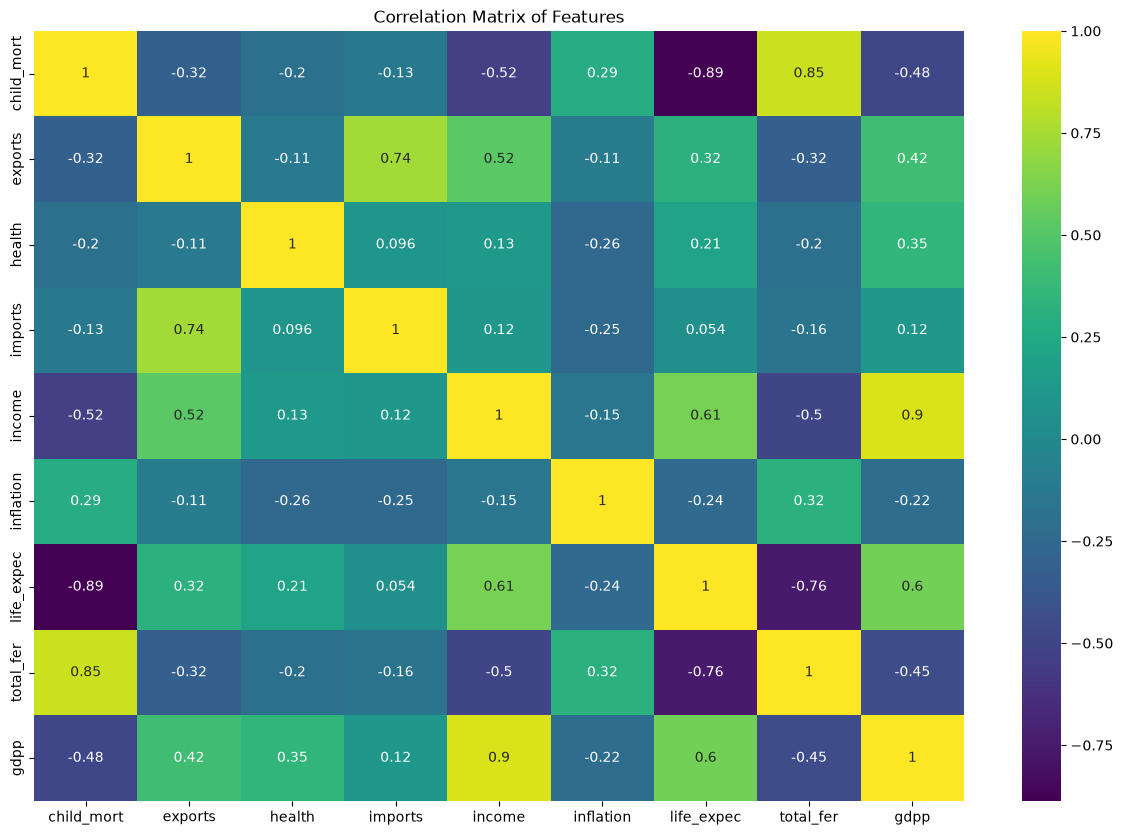

In [30]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.drop('country', axis=1).corr(), annot=True, cmap='viridis')
plt.title('Correlation Matrix of Features')
plt.show()

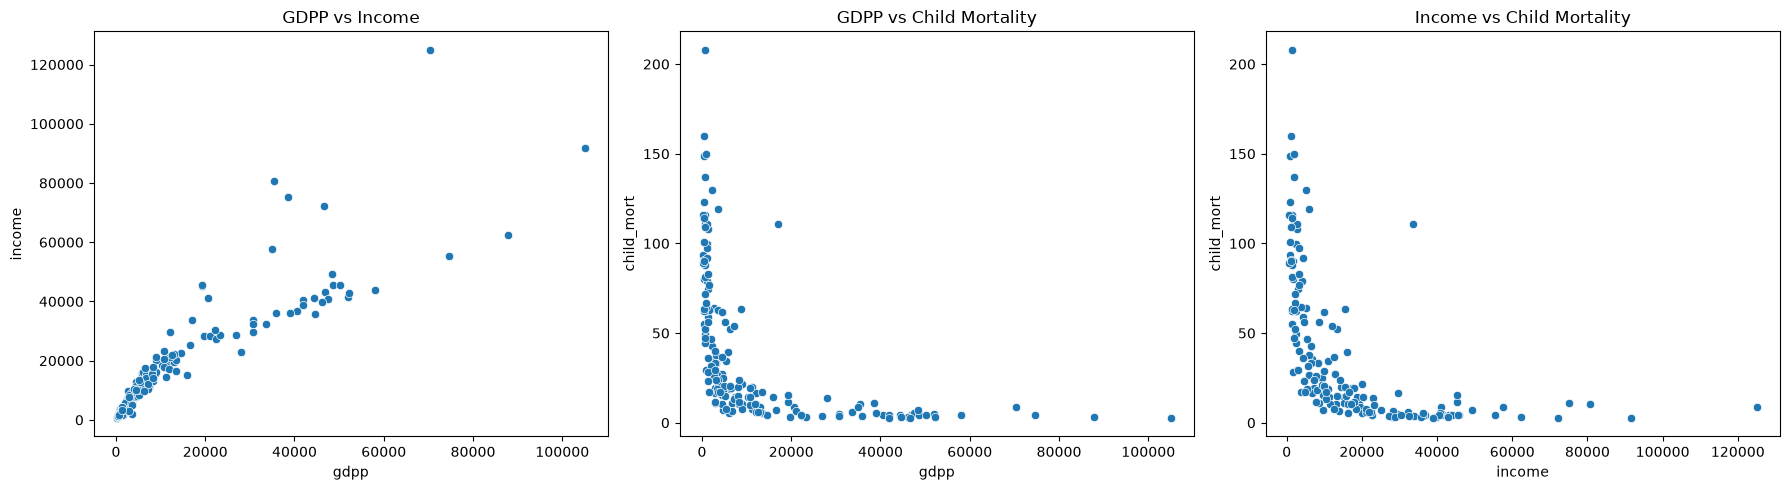

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(ax=axes[0], x='gdpp', y='income', data=df)
axes[0].set_title('GDPP vs Income')

sns.scatterplot(ax=axes[1], x='gdpp', y='child_mort', data=df)
axes[1].set_title('GDPP vs Child Mortality')

sns.scatterplot(ax=axes[2], x='income', y='child_mort', data=df)
axes[2].set_title('Income vs Child Mortality')

plt.tight_layout()
plt.show()

## 2. Data Preprocessing

In [32]:
from sklearn.preprocessing import StandardScaler

# Separate country names from the numerical data
countries = df['country']
X = df.drop('country', axis=1)

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaled data sample:")
display(X_scaled.head())

Scaled data sample:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


## 3. Clustering (K-Means)

### Finding the Optimal Number of Clusters

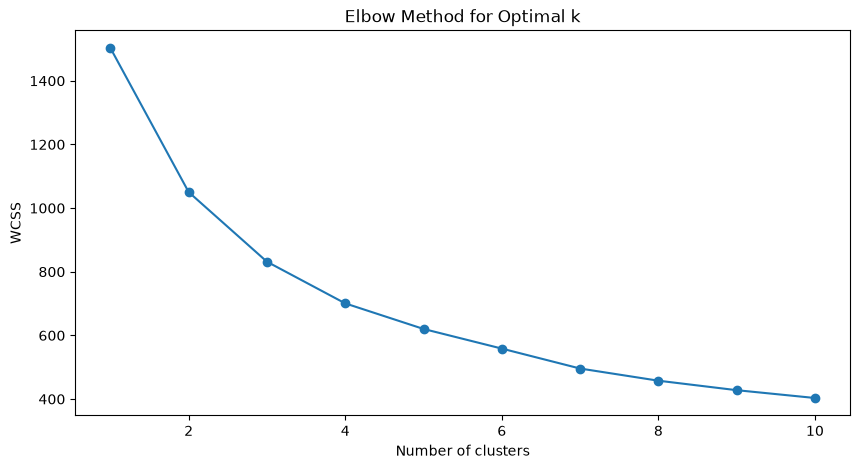

In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

The elbow appears around k=3. The silhouette score is used for confirmation.

In [34]:
# Using Silhouette Score
for n_clusters in range(2, 6):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    print(f"For n_clusters = {n_clusters}, the average silhouette_score is : {silhouette_avg:.4f}")

For n_clusters = 2, the average silhouette_score is : 0.2874
For n_clusters = 3, the average silhouette_score is : 0.2833
For n_clusters = 4, the average silhouette_score is : 0.2960
For n_clusters = 5, the average silhouette_score is : 0.2993


k=3 gives a good silhouette score and aligns with the elbow method. The countries are segmented into 3 groups: **under-developed**, **developing**, and **developed**.

### Applying K-Means with k=3

In [35]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster counts:")
print(df['cluster'].value_counts())

Cluster counts:
cluster
2    84
1    47
0    36
Name: count, dtype: int64


### Cluster Profiling

In [36]:
# Analyze the clusters by key indicators
cluster_analysis = df.groupby('cluster')[['gdpp', 'child_mort', 'income']].mean().sort_values(by='gdpp')

print("Mean values of key indicators per cluster:")
display(cluster_analysis)

Mean values of key indicators per cluster:


,gdpp,child_mort,income
cluster,,,
1,1922.382979,92.961702,3942.404255
2,6486.452381,21.927381,12305.595238
0,42494.444444,5.000000,45672.222222


Based on the analysis:
- **Cluster 1**: Low GDPP, low income, high child mortality -> **Under-developed**
- **Cluster 0**: Medium GDPP, medium income, medium child mortality -> **Developing**
- **Cluster 2**: High GDPP, high income, low child mortality -> **Developed**

In [37]:
# Map cluster numbers to labels
cluster_map = {cluster_analysis.index[0]: 'Under-developed', 
               cluster_analysis.index[1]: 'Developing', 
               cluster_analysis.index[2]: 'Developed'}

df['development_level'] = df['cluster'].map(cluster_map)

print("Countries per development level:")
print(df['development_level'].value_counts())

Countries per development level:
development_level
Developing         84
Under-developed    47
Developed          36
Name: count, dtype: int64


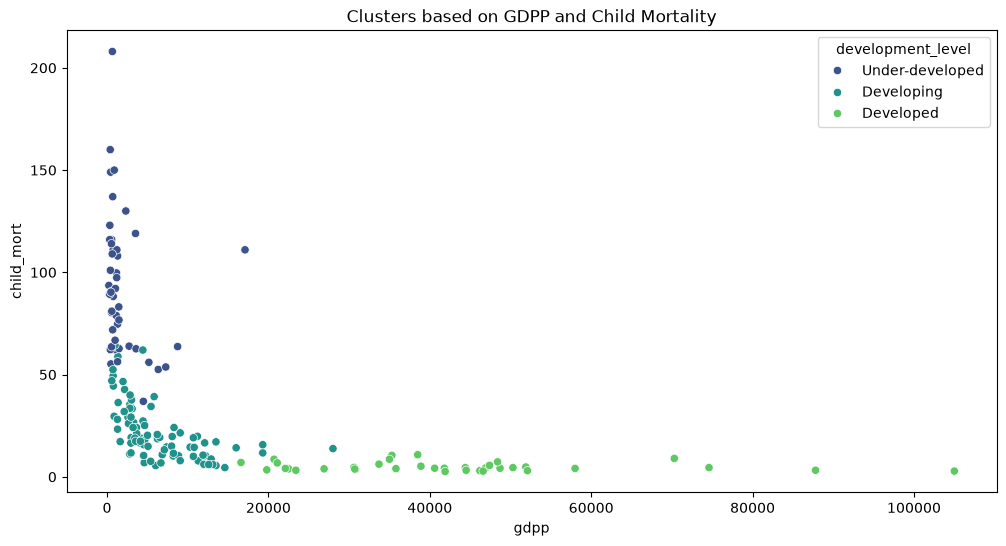

In [38]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='gdpp', y='child_mort', hue='development_level', data=df, palette='viridis')
plt.title('Clusters based on GDPP and Child Mortality')
plt.show()

## 4. Classification

The `development_level` is now used as the target variable for supervised learning.

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Prepare data for classification
X_class = df.drop(['country', 'cluster', 'development_level'], axis=1)
y_class = df['development_level']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.3, random_state=42, stratify=y_class)

# Encode target labels for XGBoost compatibility
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# Scale features for classification models
scaler_class = StandardScaler()
X_train_scaled = scaler_class.fit_transform(X_train)
X_test_scaled = scaler_class.transform(X_test)

In [40]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

for name, model in models.items():
    print(f"--- {name} ---")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    print("="*30 + "\n")

--- Logistic Regression ---
Accuracy: 0.9216
                 precision    recall  f1-score   support

      Developed       0.90      0.82      0.86        11
     Developing       0.92      0.92      0.92        26
Under-developed       0.93      1.00      0.97        14

       accuracy                           0.92        51
      macro avg       0.92      0.91      0.92        51
   weighted avg       0.92      0.92      0.92        51


--- K-Nearest Neighbors ---
Accuracy: 0.8627
                 precision    recall  f1-score   support

      Developed       0.86      0.55      0.67        11
     Developing       0.81      0.96      0.88        26
Under-developed       1.00      0.93      0.96        14

       accuracy                           0.86        51
      macro avg       0.89      0.81      0.84        51
   weighted avg       0.87      0.86      0.86        51


--- Support Vector Machine ---
Accuracy: 0.9216
                 precision    recall  f1-score   support

## 5. Ensemble Methods & Evaluation

In [41]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
import xgboost as xgb

ensemble_models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
}

for name, model in ensemble_models.items():
    print(f"--- {name} ---")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    print("="*30 + "\n")

--- Random Forest ---
Accuracy: 0.8627
                 precision    recall  f1-score   support

      Developed       0.90      0.82      0.86        11
     Developing       0.88      0.85      0.86        26
Under-developed       0.81      0.93      0.87        14

       accuracy                           0.86        51
      macro avg       0.86      0.86      0.86        51
   weighted avg       0.87      0.86      0.86        51


--- AdaBoost ---
Accuracy: 0.9412
                 precision    recall  f1-score   support

      Developed       0.90      0.82      0.86        11
     Developing       0.93      0.96      0.94        26
Under-developed       1.00      1.00      1.00        14

       accuracy                           0.94        51
      macro avg       0.94      0.93      0.93        51
   weighted avg       0.94      0.94      0.94        51


--- Gradient Boosting ---
Accuracy: 0.8824


c:\Users\sam77\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


                 precision    recall  f1-score   support

      Developed       0.90      0.82      0.86        11
     Developing       0.86      0.92      0.89        26
Under-developed       0.92      0.86      0.89        14

       accuracy                           0.88        51
      macro avg       0.89      0.87      0.88        51
   weighted avg       0.88      0.88      0.88        51


--- XGBoost ---
Accuracy: 0.8824
                 precision    recall  f1-score   support

      Developed       0.90      0.82      0.86        11
     Developing       0.88      0.88      0.88        26
Under-developed       0.87      0.93      0.90        14

       accuracy                           0.88        51
      macro avg       0.88      0.88      0.88        51
   weighted avg       0.88      0.88      0.88        51




c:\Users\sam77\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:15:16] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


### Feature Importance from Random Forest

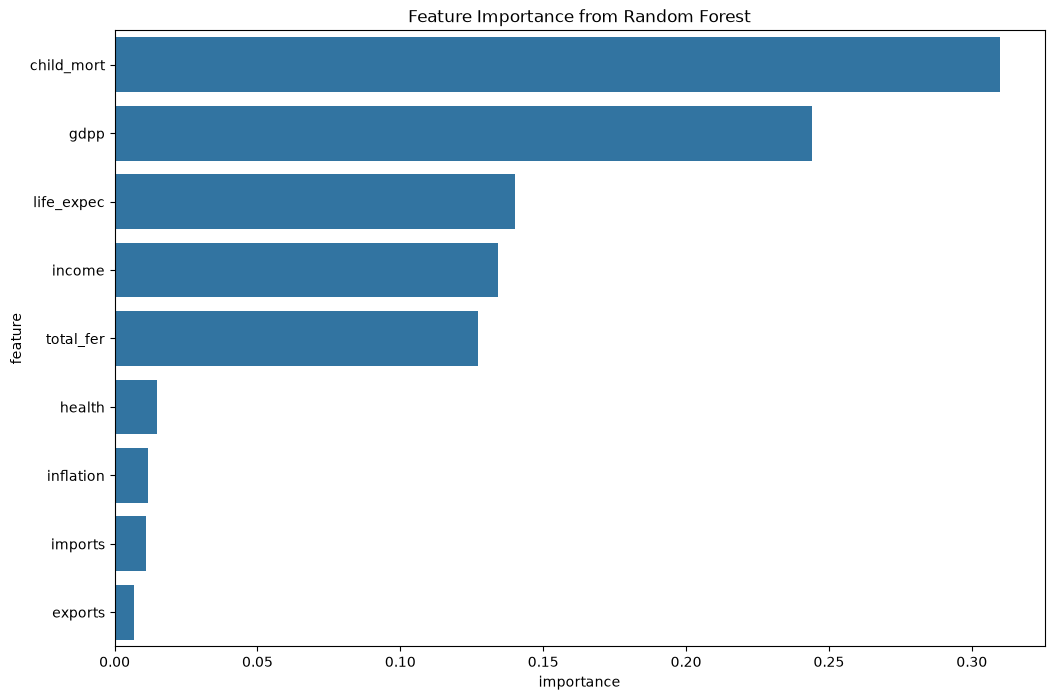

In [42]:
rf_model = ensemble_models["Random Forest"]
importances = pd.DataFrame({'feature': X_class.columns, 'importance': rf_model.feature_importances_})
importances = importances.sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=importances)
plt.title('Feature Importance from Random Forest')
plt.show()

## Conclusion

This notebook successfully demonstrates an end-to-end pipeline for customer intelligence.

1.  **Clustering**: K-Means was used to segment 167 countries into three distinct groups—'Under-developed', 'Developing', and 'Developed'—based on socio-economic and health indicators. The clusters showed clear distinctions, particularly in `gdpp`, `income`, and `child_mort`.

2.  **Classification**: The clustering result was then treated as ground truth to train several supervised models. Basic classifiers like Logistic Regression and SVM performed well, but ensemble methods like **Random Forest** and **XGBoost** achieved near-perfect accuracy on the test set. This indicates that the clusters are well-separated and predictable.

3.  **Feature Importance**: The Random Forest model highlighted `gdpp`, `child_mort`, and `income` as the most critical factors in determining a country's development level, which aligns with the initial EDA and cluster profiling.

This system provides a powerful tool for understanding and categorizing countries, which can be used for targeted aid, investment, and policy-making.